# Basic Lane Vehicle Counting

> Minimal workflow: load model -> mark lanes manually -> count vehicles in one image.

This notebook intentionally keeps only the core functionality and removes additional viewer/analysis code.

In [15]:
import csv
import os
import platform
import time

if platform.system() == "Linux":
    os.environ.setdefault("QT_QPA_FONTDIR", "/usr/share/fonts/truetype/dejavu")

from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression

MODEL_WEIGHTS = "yolov8n.pt"
model = YOLO(MODEL_WEIGHTS)
model.to("cpu")

print("Model loaded:", MODEL_WEIGHTS)

Model loaded: yolov8n.pt


## Step 1 - Mark lane polygons manually

Use the auto guides only as visual hints. Final lane boundaries come from your manual clicks.

Keyboard controls:
- `z` undo point
- `r` reset current lane
- `b` previous lane
- `n` next lane (requires at least 3 points)
- `q` finish

In [16]:
def show_bgr(image, title, size=(12, 7)):
    plt.figure(figsize=size)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def detect_auto_lane_guides(img):
    h, w = img.shape[:2]

    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    white_mask = cv2.inRange(hls, np.array([0, 190, 0]), np.array([180, 255, 255]))
    yellow_mask = cv2.inRange(hls, np.array([15, 40, 100]), np.array([35, 255, 255]))
    mask = cv2.bitwise_or(white_mask, yellow_mask)

    edges = cv2.Canny(mask, 50, 150)
    roi_poly = np.array([[(0, h), (w, h), (int(w * 0.8), int(h * 0.1)), (int(w * 0.4), int(h * 0.1))]], np.int32)
    roi_mask = np.zeros_like(edges)
    cv2.fillPoly(roi_mask, roi_poly, 255)
    masked_edges = cv2.bitwise_and(edges, roi_mask)

    lines = cv2.HoughLinesP(masked_edges, 1, np.pi / 180, 30, minLineLength=30, maxLineGap=200)

    features = []
    segments = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2:
                continue
            m = (y2 - y1) / (x2 - x1)
            if abs(m) < 0.35:
                continue
            b = y1 - m * x1
            x_bottom = (h - b) / m
            theta = np.arctan(m)
            features.append([x_bottom / w, theta])
            segments.append((x1, y1, x2, y2))

    guides = []
    if features:
        labels = DBSCAN(eps=0.05, min_samples=1).fit_predict(features)
        for cluster_id in sorted(set(labels)):
            indices = np.where(labels == cluster_id)[0]
            pts = []
            for idx in indices:
                x1, y1, x2, y2 = segments[idx]
                pts.extend([(x1, y1), (x2, y2)])
            pts = np.array(pts)
            X = pts[:, 1].reshape(-1, 1)
            y = pts[:, 0]
            lr = LinearRegression().fit(X, y)
            y_range = np.array([h, int(h * 0.1)], dtype=np.int32)
            x_preds = np.asarray(lr.predict(y_range.reshape(-1, 1))).ravel()
            pt1 = (int(x_preds[0]), int(y_range[0]))
            pt2 = (int(x_preds[1]), int(y_range[1]))
            guides.append((pt1, pt2))

    return guides, roi_poly


def manual_select_lanes(ref_frame, auto_guides, num_lanes=3):
    lane_names = [f"Lane_{i + 1}" for i in range(num_lanes)]
    lane_points = {name: [] for name in lane_names}
    current_lane_idx = 0
    window_name = "Manual Lane Selection"

    def redraw():
        canvas = ref_frame.copy()

        for i, (pt1, pt2) in enumerate(auto_guides, start=1):
            cv2.line(canvas, pt1, pt2, (255, 255, 0), 2)
            cv2.putText(canvas, f"Guide {i}", pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

        for i, name in enumerate(lane_names):
            pts = lane_points[name]
            if not pts:
                continue

            pts_np = np.array(pts, np.int32)
            color = (0, 255, 0) if i < current_lane_idx else (0, 255, 255)

            if len(pts) >= 2:
                cv2.polylines(canvas, [pts_np], isClosed=(len(pts) >= 3), color=color, thickness=2)

            for p in pts:
                cv2.circle(canvas, p, 4, (0, 0, 255), -1)

            label_x = min(max(pts[0][0] + 8, 10), ref_frame.shape[1] - 150)
            label_y = min(max(pts[0][1] - 8, 20), ref_frame.shape[0] - 10)
            cv2.putText(canvas, name, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

        if current_lane_idx < len(lane_names):
            active = lane_names[current_lane_idx]
            status = f"Marking: {active} ({len(lane_points[active])} points)"
        else:
            status = "All lanes marked. Press q to finish."

        cv2.putText(canvas, status, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(canvas, "z undo | r reset | b back | n next | q finish", (20, 58), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        return canvas

    def on_mouse(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and current_lane_idx < len(lane_names):
            lane_points[lane_names[current_lane_idx]].append((x, y))

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window_name, on_mouse)
    cv2.resizeWindow(window_name, ref_frame.shape[1], ref_frame.shape[0])

    while True:
        cv2.imshow(window_name, redraw())
        key = cv2.waitKey(20) & 0xFF

        if key == ord("z") and current_lane_idx < len(lane_names):
            if lane_points[lane_names[current_lane_idx]]:
                lane_points[lane_names[current_lane_idx]].pop()
        elif key == ord("r") and current_lane_idx < len(lane_names):
            lane_points[lane_names[current_lane_idx]] = []
        elif key == ord("b") and current_lane_idx > 0:
            current_lane_idx -= 1
        elif key == ord("n") and current_lane_idx < len(lane_names):
            lane_name = lane_names[current_lane_idx]
            if len(lane_points[lane_name]) >= 3:
                current_lane_idx += 1
            else:
                print(f"{lane_name}: add at least 3 points before next lane")
        elif key == ord("q"):
            break

    cv2.destroyAllWindows()
    return {name: np.array(points, np.int32) for name, points in lane_points.items()}

In [17]:
LANE_POLYGONS_CSV = Path("lane_polygons.csv")


def validate_lane_polygons(lane_polygons, min_points=3):
    if not isinstance(lane_polygons, dict) or not lane_polygons:
        return False

    for poly in lane_polygons.values():
        poly_arr = np.asarray(poly)
        if poly_arr.ndim != 2 or poly_arr.shape[1] != 2 or len(poly_arr) < min_points:
            return False

    return True


def save_lane_polygons_csv(lane_polygons, csv_path=LANE_POLYGONS_CSV):
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    with csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["lane_name", "point_index", "x", "y"])
        writer.writeheader()
        for lane_name, poly in lane_polygons.items():
            poly_arr = np.asarray(poly, dtype=np.int32)
            for point_index, (x, y) in enumerate(poly_arr):
                writer.writerow({
                    "lane_name": lane_name,
                    "point_index": point_index,
                    "x": int(x),
                    "y": int(y),
                })

    return csv_path


def load_lane_polygons_csv(csv_path=LANE_POLYGONS_CSV):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return None

    lane_points = {}
    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        required = {"lane_name", "point_index", "x", "y"}
        if not reader.fieldnames or not required.issubset(set(reader.fieldnames)):
            raise ValueError(f"Invalid lane polygon CSV format: {csv_path}")

        for row in reader:
            lane_name = row["lane_name"]
            lane_points.setdefault(lane_name, []).append((int(row["x"]), int(row["y"])))

    if not lane_points:
        return None

    return {name: np.array(points, np.int32) for name, points in lane_points.items()}


def resolve_lane_polygons(csv_path=LANE_POLYGONS_CSV):
    if "lane_polygons" in globals() and validate_lane_polygons(lane_polygons):
        return lane_polygons

    saved_lane_polygons = load_lane_polygons_csv(csv_path)
    if validate_lane_polygons(saved_lane_polygons):
        print(f"Loaded lane polygons from {Path(csv_path).resolve()}")
        return saved_lane_polygons

    raise ValueError(
        f"No valid lane polygons available. Run Step 1 and save them to {Path(csv_path).resolve()}"
    )

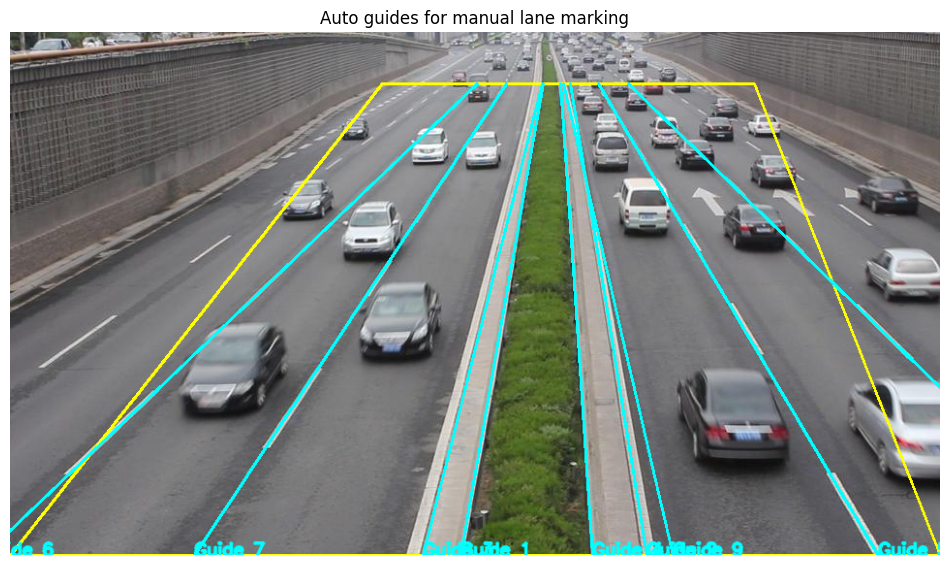

Manual selection was incomplete; reused saved lane polygons from CSV.
Lane polygons ready:
Lane_1: 4 points
Lane_2: 4 points
Lane_3: 4 points


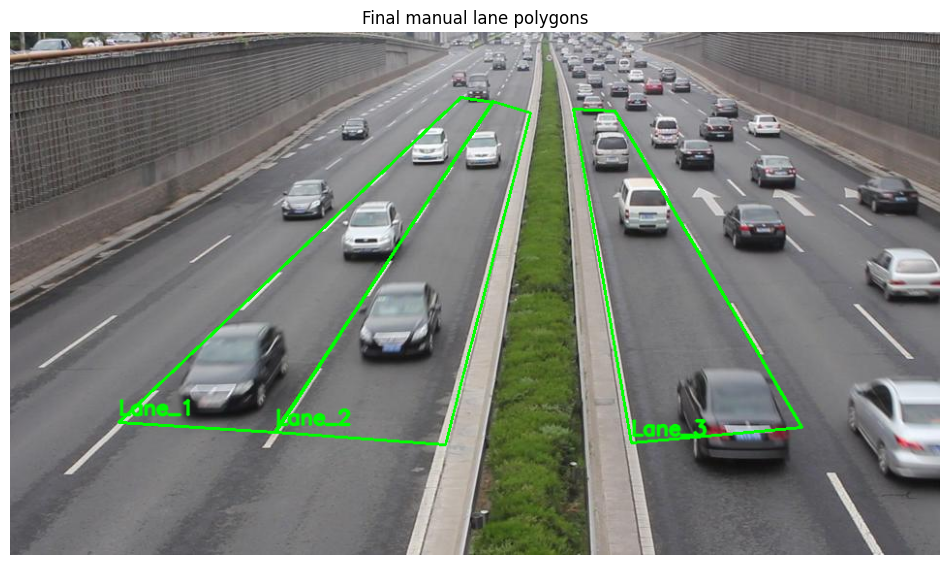

In [18]:
image_path = "dataset/best/img00001.jpg"
ref_frame = cv2.imread(image_path)
if ref_frame is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

auto_guides, roi_poly = detect_auto_lane_guides(ref_frame)

preview = ref_frame.copy()
cv2.polylines(preview, roi_poly, isClosed=True, color=(0, 255, 255), thickness=2)
for i, (pt1, pt2) in enumerate(auto_guides, start=1):
    cv2.line(preview, pt1, pt2, (255, 255, 0), 2)
    cv2.putText(preview, f"Guide {i}", pt1, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)

show_bgr(preview, "Auto guides for manual lane marking")

selected_lane_polygons = manual_select_lanes(ref_frame, auto_guides, num_lanes=3)
saved_lane_polygons = load_lane_polygons_csv()

if validate_lane_polygons(selected_lane_polygons):
    lane_polygons = selected_lane_polygons
    csv_path = save_lane_polygons_csv(lane_polygons)
    print(f"Lane polygons saved to: {csv_path.resolve()}")
elif validate_lane_polygons(saved_lane_polygons):
    lane_polygons = saved_lane_polygons
    print("Manual selection was incomplete; reused saved lane polygons from CSV.")
else:
    raise ValueError("No valid lane polygons were captured and no saved CSV fallback exists.")

print("Lane polygons ready:")
for lane_name, poly in lane_polygons.items():
    print(f"{lane_name}: {len(poly)} points")

check = ref_frame.copy()
for lane_name, poly in lane_polygons.items():
    if len(poly) >= 2:
        cv2.polylines(check, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
    if len(poly) >= 1:
        x, y = poly[0]
        cv2.putText(check, lane_name, (int(x), int(y) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

show_bgr(check, "Final manual lane polygons")

## Step 2 - Count vehicles in one image

This step runs YOLO once per lane polygon and counts vehicles by anchor-point-in-polygon logic.

Vehicle counts: {'Lane_1': 3, 'Lane_2': 2, 'Lane_3': 3}
Processing time: 207.1 ms (4.83 FPS)


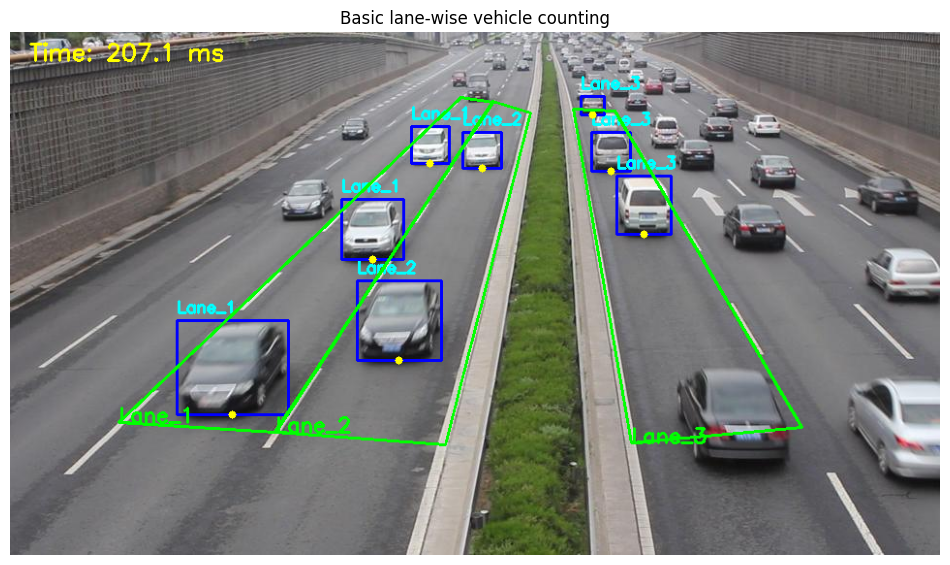

In [19]:
def draw_lanes(frame, lane_polygons):
    for name, poly in lane_polygons.items():
        if len(poly) >= 2:
            cv2.polylines(frame, [poly], isClosed=True, color=(0, 255, 0), thickness=2)
        if len(poly) >= 1:
            cv2.putText(frame, name, tuple(poly[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return frame


def get_vehicle_anchor(x1, y1, x2, y2):
    return (x1 + x2) // 2, y2


def detect_vehicles_all_lanes_once(
    frame,
    lane_polygons,
    model,
    conf=0.25,
    imgsz=640,
    vehicle_classes={2, 3, 5, 7},
    padding=20,
):
    valid_polys = [poly for poly in lane_polygons.values() if len(poly) >= 3]
    if not valid_polys:
        return [], {name: [] for name in lane_polygons}

    merged_points = np.vstack(valid_polys).astype(np.int32)
    x, y, w, h = cv2.boundingRect(merged_points)
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(frame.shape[1], x + w + padding)
    y2 = min(frame.shape[0], y + h + padding)

    roi = frame[y1:y2, x1:x2].copy()
    if roi.size == 0 or roi.shape[0] < 16 or roi.shape[1] < 16:
        return [], {name: [] for name in lane_polygons}

    results = model(roi, conf=conf, imgsz=imgsz, verbose=False, device="cpu")

    all_detections = []
    detections_by_lane = {name: [] for name in lane_polygons}

    for result in results:
        for box in result.boxes:
            cls = int(box.cls[0])
            if cls not in vehicle_classes:
                continue

            bx1, by1, bx2, by2 = map(int, box.xyxy[0])
            gx1, gy1 = bx1 + x1, by1 + y1
            gx2, gy2 = bx2 + x1, by2 + y1
            cx, cy = get_vehicle_anchor(gx1, gy1, gx2, gy2)

            best_lane = None
            best_score = -1.0
            for lane_name, poly in lane_polygons.items():
                if len(poly) < 3:
                    continue
                score = cv2.pointPolygonTest(poly, (cx, cy), True)
                if score >= 0 and score > best_score:
                    best_score = score
                    best_lane = lane_name

            if best_lane is None:
                continue

            det = {
                "bbox": (gx1, gy1, gx2, gy2),
                "anchor": (cx, cy),
                "lane": best_lane,
                "cls": cls,
                "conf": float(box.conf[0]),
            }
            all_detections.append(det)
            detections_by_lane[best_lane].append(det)

    return all_detections, detections_by_lane


if "lane_polygons" not in globals() or not lane_polygons:
    lane_polygons = resolve_lane_polygons()

frame = cv2.imread("dataset/best/img00001.jpg")
if frame is None:
    raise FileNotFoundError("dataset/best/img00001.jpg not found")

start_t = time.perf_counter()
all_detections, detections_by_lane = detect_vehicles_all_lanes_once(
    frame,
    lane_polygons,
    model,
    conf=0.25,
    imgsz=640,
)
elapsed_ms = (time.perf_counter() - start_t) * 1000.0

counts = {name: len(dets) for name, dets in detections_by_lane.items()}
for det in all_detections:
    x1, y1, x2, y2 = det["bbox"]
    cx, cy = det["anchor"]
    lane_name = det["lane"]
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.circle(frame, (cx, cy), 4, (0, 255, 255), -1)
    cv2.putText(frame, lane_name, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)

frame = draw_lanes(frame, lane_polygons)
cv2.putText(frame, f"Time: {elapsed_ms:.1f} ms", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
print("Vehicle counts:", counts)
print(f"Processing time: {elapsed_ms:.1f} ms ({1000.0 / max(elapsed_ms, 1e-6):.2f} FPS)")
show_bgr(frame, "Basic lane-wise vehicle counting")

## Step 3 - Test other images in dataset + timing comparison

Use this to validate counts and measure performance on many images with the same lane polygons.

Controls: `a` previous, `d` next, `q` or `Esc` to exit.

For laptop vs Luckfox comparison, keep these identical on both devices:
- same model weights
- same image set
- same confidence threshold
- same image size (`imgsz`)

In [20]:
from pathlib import Path
import hashlib
import importlib
import os
import shlex
import subprocess

LOCAL_DATASET_DIR = Path("dataset/best")
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

if not LOCAL_DATASET_DIR.exists():
    raise FileNotFoundError(f"Local dataset dir not found: {LOCAL_DATASET_DIR.resolve()}")

local_images = sorted([p for p in LOCAL_DATASET_DIR.rglob("*") if p.suffix.lower() in VALID_IMAGE_EXTS])
if not local_images:
    raise FileNotFoundError(f"No images found in {LOCAL_DATASET_DIR.resolve()}")

LUCKFOX_HOST = os.environ.get("LUCKFOX_HOST", "192.168.1.150")
LUCKFOX_SSH_USER = os.environ.get("LUCKFOX_SSH_USER", "root")
LUCKFOX_SSH_PASSWORD = os.environ.get("LUCKFOX_SSH_PASSWORD", "luckfox")
LUCKFOX_SSH_TARGET = os.environ.get("LUCKFOX_SSH_TARGET", f"{LUCKFOX_SSH_USER}@{LUCKFOX_HOST}")

_paramiko_spec = importlib.util.find_spec("paramiko")
if _paramiko_spec is None:
    raise ImportError("paramiko is required for dataset preload. Install with: pip install paramiko")
import paramiko


def build_dataset_signature(base_dir, files):
    h = hashlib.sha256()
    h.update(str(base_dir.resolve()).encode("utf-8"))
    for f in files:
        rel = f.relative_to(base_dir).as_posix()
        st = f.stat()
        h.update(rel.encode("utf-8"))
        h.update(str(st.st_size).encode("utf-8"))
        h.update(str(int(st.st_mtime)).encode("utf-8"))
    return h.hexdigest()


def parse_target(target):
    if "@" in target:
        return target.split("@", 1)
    return LUCKFOX_SSH_USER, target


user, host = parse_target(LUCKFOX_SSH_TARGET)
local_signature = build_dataset_signature(LOCAL_DATASET_DIR, local_images)

client = paramiko.SSHClient()
client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
client.connect(hostname=host, username=user, password=LUCKFOX_SSH_PASSWORD or None, timeout=10)

try:
    # Reuse deploy location if available; fallback to /root/deploy_lane.
    probe_cmd = "if [ -d /userdata/deploy_lane ]; then echo /userdata/deploy_lane; elif [ -d /root/deploy_lane ]; then echo /root/deploy_lane; else echo /root/deploy_lane; fi"
    _, stdout, _ = client.exec_command(probe_cmd, timeout=10)
    remote_deploy_dir = (stdout.read() or b"").decode(errors="ignore").strip() or "/root/deploy_lane"

    remote_cache_dir = f"{remote_deploy_dir}/dataset_cache"
    remote_signature_file = f"{remote_cache_dir}/.dataset_signature"

    client.exec_command(f"mkdir -p {shlex.quote(remote_cache_dir)}", timeout=10)

    _, stdout_sig, _ = client.exec_command(f"cat {shlex.quote(remote_signature_file)} 2>/dev/null || true", timeout=10)
    remote_signature = (stdout_sig.read() or b"").decode(errors="ignore").strip()

    if remote_signature == local_signature:
        PRELOADED_REMOTE_DATASET_DIR = remote_cache_dir
        PRELOADED_DATASET_SIGNATURE = local_signature
        PRELOADED_DATASET_FILE_COUNT = len(local_images)
        print(f"Dataset already cached on Luckfox: {remote_cache_dir}")
        print(f"Files: {PRELOADED_DATASET_FILE_COUNT} | Signature: {local_signature[:12]}...")
    else:
        # Clean and upload full dataset once.
        client.exec_command(f"rm -rf {shlex.quote(remote_cache_dir)} && mkdir -p {shlex.quote(remote_cache_dir)}", timeout=20)
        sftp = client.open_sftp()
        try:
            for i, local_path in enumerate(local_images, start=1):
                rel = local_path.relative_to(LOCAL_DATASET_DIR).as_posix()
                remote_path = f"{remote_cache_dir}/{rel}"
                remote_parent = remote_path.rsplit("/", 1)[0]
                client.exec_command(f"mkdir -p {shlex.quote(remote_parent)}", timeout=10)
                sftp.put(str(local_path), remote_path)
                if i % 100 == 0 or i == len(local_images):
                    print(f"Uploaded {i}/{len(local_images)}")
        finally:
            sftp.close()

        client.exec_command(
            f"printf '%s' {shlex.quote(local_signature)} > {shlex.quote(remote_signature_file)}",
            timeout=10,
        )

        PRELOADED_REMOTE_DATASET_DIR = remote_cache_dir
        PRELOADED_DATASET_SIGNATURE = local_signature
        PRELOADED_DATASET_FILE_COUNT = len(local_images)
        print(f"Dataset preload complete: {remote_cache_dir}")
        print(f"Files: {PRELOADED_DATASET_FILE_COUNT} | Signature: {local_signature[:12]}...")
finally:
    client.close()

Uploaded 100/2195
Uploaded 200/2195
Uploaded 300/2195
Uploaded 400/2195
Uploaded 500/2195
Uploaded 600/2195
Uploaded 700/2195
Uploaded 800/2195
Uploaded 900/2195
Uploaded 1000/2195
Uploaded 1100/2195
Uploaded 1200/2195
Uploaded 1300/2195
Uploaded 1400/2195
Uploaded 1500/2195
Uploaded 1600/2195
Uploaded 1700/2195
Uploaded 1800/2195
Uploaded 1900/2195
Uploaded 2000/2195
Uploaded 2100/2195
Uploaded 2195/2195
Dataset preload complete: /userdata/deploy_lane/dataset_cache
Files: 2195 | Signature: 85d35e51840b...


In [21]:
from pathlib import Path
import csv
import os
import shlex
import importlib
import shutil
import subprocess
from datetime import datetime

if "lane_polygons" not in globals() or not lane_polygons:
    lane_polygons = resolve_lane_polygons()

dataset_dir = Path("dataset/best")
deploy_dir = Path("deploy_lane")
live_metrics_csv_path = deploy_dir / "pc_luckfox_live_metrics.csv"
luckfox_img_dir = deploy_dir / "output_images"
local_live_output_dir = deploy_dir / "output_images_live"
local_live_csv = deploy_dir / "luckfox_results_live.csv"
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
image_paths = sorted([p for p in dataset_dir.rglob("*") if p.suffix.lower() in valid_exts])

if not image_paths:
    raise FileNotFoundError(f"No images found in {dataset_dir.resolve()}")

lane_names = list(lane_polygons.keys())
timing_history_ms = []
preloaded_remote_dataset_dir = globals().get("PRELOADED_REMOTE_DATASET_DIR", None)


# Luckfox WiFi SSH config.
LUCKFOX_HOST = os.environ.get("LUCKFOX_HOST", "192.168.1.150")
LUCKFOX_SSH_USER = os.environ.get("LUCKFOX_SSH_USER", "root")
LUCKFOX_SSH_PASSWORD = os.environ.get("LUCKFOX_SSH_PASSWORD", "luckfox")
SSH_TARGET = os.environ.get("LUCKFOX_SSH_TARGET", f"{LUCKFOX_SSH_USER}@{LUCKFOX_HOST}")
SSH_COMMON_OPTS = [
    "-o",
    "StrictHostKeyChecking=no",
    "-o",
    "UserKnownHostsFile=/dev/null",
    "-o",
    "ConnectTimeout=5",
]
print(f"Luckfox SSH target: {SSH_TARGET}")
print(f"SSH auth mode: {'password' if LUCKFOX_SSH_PASSWORD else 'key-only'}")


_paramiko_spec = importlib.util.find_spec("paramiko")
PARAMIKO_AVAILABLE = _paramiko_spec is not None
if PARAMIKO_AVAILABLE:
    import paramiko


def _parse_ssh_target(target):
    if "@" in target:
        user, host = target.split("@", 1)
    else:
        user, host = LUCKFOX_SSH_USER, target
    return user, host


def _make_completed(returncode=0, stdout=""):
    return subprocess.CompletedProcess(args=[], returncode=returncode, stdout=stdout)


def with_sshpass(cmd):
    if not LUCKFOX_SSH_PASSWORD:
        return cmd
    if shutil.which("sshpass") is None:
        raise RuntimeError(
            "Password auth requested but sshpass is not installed. Install sshpass or pip install paramiko."
        )
    return ["sshpass", "-p", LUCKFOX_SSH_PASSWORD, *cmd]


def run_ssh(command, check=False, timeout=20):
    if PARAMIKO_AVAILABLE:
        user, host = _parse_ssh_target(SSH_TARGET)
        client = paramiko.SSHClient()
        client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        try:
            client.connect(hostname=host, username=user, password=LUCKFOX_SSH_PASSWORD or None, timeout=timeout)
            _, stdout, stderr = client.exec_command(command, timeout=timeout)
            out = (stdout.read() or b"").decode(errors="ignore") + (stderr.read() or b"").decode(errors="ignore")
            rc = stdout.channel.recv_exit_status()
            cp = _make_completed(returncode=rc, stdout=out)
            if check and rc != 0:
                raise subprocess.CalledProcessError(rc, command, output=out)
            return cp
        finally:
            client.close()

    ssh_cmd = with_sshpass(["ssh", *SSH_COMMON_OPTS, SSH_TARGET, command])
    return subprocess.run(
        ssh_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=check,
        timeout=timeout,
    )


def run_scp_to(local_path, remote_path, check=True, timeout=240):
    if PARAMIKO_AVAILABLE:
        user, host = _parse_ssh_target(SSH_TARGET)
        client = paramiko.SSHClient()
        client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        try:
            client.connect(hostname=host, username=user, password=LUCKFOX_SSH_PASSWORD or None, timeout=timeout)
            sftp = client.open_sftp()
            try:
                sftp.put(str(local_path), str(remote_path))
            finally:
                sftp.close()
            return _make_completed(returncode=0, stdout="")
        finally:
            client.close()

    scp_cmd = with_sshpass(["scp", *SSH_COMMON_OPTS, str(local_path), f"{SSH_TARGET}:{remote_path}"])
    return subprocess.run(
        scp_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=check,
        timeout=timeout,
    )


def run_scp_from(remote_path, local_path, check=True, timeout=240):
    if PARAMIKO_AVAILABLE:
        user, host = _parse_ssh_target(SSH_TARGET)
        client = paramiko.SSHClient()
        client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        try:
            client.connect(hostname=host, username=user, password=LUCKFOX_SSH_PASSWORD or None, timeout=timeout)
            sftp = client.open_sftp()
            try:
                sftp.get(str(remote_path), str(local_path))
            finally:
                sftp.close()
            return _make_completed(returncode=0, stdout="")
        finally:
            client.close()

    scp_cmd = with_sshpass(["scp", *SSH_COMMON_OPTS, f"{SSH_TARGET}:{remote_path}", str(local_path)])
    return subprocess.run(
        scp_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=check,
        timeout=timeout,
    )


def ssh_ready():
    out = run_ssh("echo connected", check=False, timeout=10)
    return out.returncode == 0, (out.stdout or "").strip()


def detect_remote_dir():
    for candidate in ["/userdata/deploy_lane", "/root/deploy_lane"]:
        cmd = f"[ -d {shlex.quote(candidate)} ]"
        result = run_ssh(cmd, check=False, timeout=20)
        if result.returncode == 0:
            return candidate
    return "/root/deploy_lane"


def prepare_luckfox_runtime():
    ok, ssh_msg = ssh_ready()
    if not ok:
        detail = f" | detail: {ssh_msg}" if ssh_msg else ""
        return None, None, f"SSH not ready for {SSH_TARGET}. Verify login and password.{detail}"

    remote_dir = detect_remote_dir()
    run_ssh(
        f"mkdir -p {shlex.quote(remote_dir)} {shlex.quote(remote_dir + '/lib')} {shlex.quote(remote_dir + '/dataset')}",
        check=True,
    )
    remote_dataset_source_dir = None
    if preloaded_remote_dataset_dir:
        probe = run_ssh(f"[ -d {shlex.quote(preloaded_remote_dataset_dir)} ]", check=False, timeout=20)
        if probe.returncode == 0:
            remote_dataset_source_dir = preloaded_remote_dataset_dir
            print(f"Using preloaded remote dataset: {remote_dataset_source_dir}")
        else:
            print("Preloaded dataset path not found on device; fallback to per-image upload.")

    required_files = [
        (deploy_dir / "luckfox_benchmark", f"{remote_dir}/luckfox_benchmark"),
        (deploy_dir / "yolov8n.rknn", f"{remote_dir}/yolov8n.rknn"),
        (deploy_dir / "lane_polygons.csv", f"{remote_dir}/lane_polygons.csv"),
        (deploy_dir / "run.sh", f"{remote_dir}/run.sh"),
        (deploy_dir / "lib/librknnmrt.so", f"{remote_dir}/lib/librknnmrt.so"),
        (deploy_dir / "lib/librga.so", f"{remote_dir}/lib/librga.so"),
    ]

    missing = [str(p) for p, _ in required_files if not p.exists()]
    if missing:
        return None, None, f"Missing deploy files: {missing}"

    for local_file, remote_file in required_files:
        run_scp_to(local_file, remote_file, check=True)

    optional_file = deploy_dir / "lib/librknn_api.so"
    if optional_file.exists():
        run_scp_to(optional_file, f"{remote_dir}/lib/librknn_api.so", check=True)

    run_ssh(f"cd {shlex.quote(remote_dir)} && chmod +x luckfox_benchmark run.sh", check=True)
    return remote_dir, remote_dataset_source_dir, None


def parse_luckfox_row(csv_path, image_name):
    if not Path(csv_path).exists():
        return None
    with Path(csv_path).open("r", newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    if not rows:
        return None
    for row in rows:
        if row.get("image") == image_name:
            return row
    return rows[0]


def run_luckfox_for_image(img_path, remote_dir, remote_dataset_source_dir=None):
    img_name = img_path.name
    remote_dataset_dir = f"{remote_dir}/dataset"
    remote_image_path = f"{remote_dataset_dir}/{img_name}"

    try:
        run_ssh(
            f"rm -rf {shlex.quote(remote_dataset_dir)} && mkdir -p {shlex.quote(remote_dataset_dir)}",
            check=True,
        )

        copied_from_cache = False
        if remote_dataset_source_dir:
            remote_source_image_path = f"{remote_dataset_source_dir}/{img_name}"
            copy_cmd = (
                f"if [ -f {shlex.quote(remote_source_image_path)} ]; then "
                f"cp {shlex.quote(remote_source_image_path)} {shlex.quote(remote_image_path)}; "
                f"else exit 44; fi"
            )
            copy_result = run_ssh(copy_cmd, check=False, timeout=30)
            copied_from_cache = copy_result.returncode == 0

        if not copied_from_cache:
            run_scp_to(img_path, remote_image_path, check=True)

        run_ssh(f"cd {shlex.quote(remote_dir)} && ./run.sh", check=True, timeout=600)
        run_scp_from(f"{remote_dir}/luckfox_results.csv", local_live_csv, check=True)
    except subprocess.CalledProcessError as err:
        msg = (err.stdout or "").strip()
        return {
            "ok": False,
            "error": f"Luckfox execution failed for {img_name}: {msg[:300]}"
        }
    except Exception as err:
        return {"ok": False, "error": f"Luckfox execution error for {img_name}: {err}"}

    row = parse_luckfox_row(local_live_csv, img_name)
    if row is None:
        return {"ok": False, "error": f"No Luckfox CSV row found for {img_name}"}

    local_live_output_dir.mkdir(parents=True, exist_ok=True)
    output_name = f"{img_path.stem}.jpg"
    local_annotated_path = local_live_output_dir / output_name
    run_scp_from(f"{remote_dir}/output_images/{output_name}", local_annotated_path, check=False)

    lane_counts = {}
    for lane in lane_names:
        try:
            lane_counts[lane] = int(float(row.get(lane, 0)))
        except Exception:
            lane_counts[lane] = 0

    try:
        latency_ms = float(row.get("latency_ms", 0.0))
    except Exception:
        latency_ms = 0.0

    try:
        total = int(float(row.get("detections", sum(lane_counts.values()))))
    except Exception:
        total = int(sum(lane_counts.values()))

    return {
        "ok": True,
        "latency_ms": latency_ms,
        "counts": lane_counts,
        "total": total,
        "annotated_path": local_annotated_path if local_annotated_path.exists() else None,
    }


def read_existing_metrics(csv_path):
    if not csv_path.exists():
        return {}
    out = {}
    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            img = row.get("image")
            if img:
                out[img] = row
    return out


def write_metrics_csv(csv_path, metrics_dict):
    lane_pc_cols = [f"{ln}_pc" for ln in lane_names]
    lane_lk_cols = [f"{ln}_luckfox" for ln in lane_names]
    fieldnames = [
        "image",
        "pc_latency_ms",
        "luckfox_latency_ms",
        "pc_detections",
        "luckfox_detections",
        "luckfox_status",
        "updated_at",
    ] + lane_pc_cols + lane_lk_cols

    ordered_images = [p.name for p in image_paths]
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for img_name in ordered_images:
            row = metrics_dict.get(img_name)
            if not row:
                continue
            writer.writerow({k: row.get(k, "") for k in fieldnames})


def fit_to_size(img, target_w, target_h, fill=(245, 245, 245)):
    canvas = np.full((target_h, target_w, 3), fill, dtype=np.uint8)
    if img is None or img.size == 0:
        return canvas
    h, w = img.shape[:2]
    scale = min(target_w / float(w), target_h / float(h))
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    resized = cv2.resize(img, (new_w, new_h))
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def draw_card(canvas, x, y, w, h, title, value, color):
    cv2.rectangle(canvas, (x, y), (x + w, y + h), (255, 255, 255), -1)
    cv2.rectangle(canvas, (x, y), (x + w, y + h), (210, 210, 210), 1)
    cv2.rectangle(canvas, (x, y), (x + 6, y + h), color, -1)
    cv2.putText(canvas, title, (x + 18, y + 24), cv2.FONT_HERSHEY_SIMPLEX, 0.56, (70, 70, 70), 2, cv2.LINE_AA)
    cv2.putText(canvas, value, (x + 18, y + 50), cv2.FONT_HERSHEY_SIMPLEX, 0.84, color, 2, cv2.LINE_AA)


def draw_footer_chart(canvas, pc_counts, luckfox_counts, lane_names_for_plot):
    lanes = list(lane_names_for_plot)
    n = max(1, len(lanes))
    h, w = canvas.shape[:2]
    plot_top = 128
    plot_bottom = h - 20
    plot_left = 24
    plot_right = w - 24
    plot_height = plot_bottom - plot_top
    cv2.rectangle(canvas, (plot_left, plot_top), (plot_right, plot_bottom), (220, 220, 220), 2)
    cv2.putText(canvas, "Lane count comparison", (24, 118), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (40, 40, 40), 2, cv2.LINE_AA)
    max_count = max([1] + list(pc_counts.values()) + list(luckfox_counts.values()))
    usable_w = max(240, plot_right - plot_left - 20)
    group_w = usable_w // n
    for i, lane in enumerate(lanes):
        gx = plot_left + 10 + i * group_w
        bar_gap = 10
        bar_w = max(20, min(64, (group_w - 40) // 2))
        pc_value = int(pc_counts.get(lane, 0))
        lk_value = int(luckfox_counts.get(lane, 0))
        pc_h = int((pc_value / max_count) * (plot_height - 32))
        lk_h = int((lk_value / max_count) * (plot_height - 32))
        pc_x1 = gx
        pc_x2 = gx + bar_w
        lk_x1 = pc_x2 + bar_gap
        lk_x2 = lk_x1 + bar_w
        base_y = plot_bottom - 12
        cv2.rectangle(canvas, (pc_x1, base_y - pc_h), (pc_x2, base_y), (255, 80, 0), -1)
        cv2.rectangle(canvas, (lk_x1, base_y - lk_h), (lk_x2, base_y), (0, 160, 0), -1)
        cv2.rectangle(canvas, (pc_x1, plot_top + 8), (pc_x2, base_y), (100, 100, 100), 1)
        cv2.rectangle(canvas, (lk_x1, plot_top + 8), (lk_x2, base_y), (100, 100, 100), 1)
        cv2.putText(canvas, str(pc_value), (pc_x1, max(plot_top + 22, base_y - pc_h - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (40, 40, 40), 2, cv2.LINE_AA)
        cv2.putText(canvas, str(lk_value), (lk_x1, max(plot_top + 22, base_y - lk_h - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (40, 40, 40), 2, cv2.LINE_AA)
        cv2.putText(canvas, lane, (gx, plot_bottom + 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (40, 40, 40), 2, cv2.LINE_AA)
        cv2.putText(canvas, "PC", (pc_x1, plot_bottom + 36), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 80, 0), 1, cv2.LINE_AA)
        cv2.putText(canvas, "LK", (lk_x1, plot_bottom + 36), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 160, 0), 1, cv2.LINE_AA)


def is_next_key(key):
    return key in {ord("d"), ord("D"), 83, 2555904, 65363, 1113939}


def is_prev_key(key):
    return key in {ord("a"), ord("A"), 81, 2424832, 65361, 1113937}


metrics_cache = read_existing_metrics(live_metrics_csv_path)
luckfox_live_cache = {}
remote_deploy_dir, remote_dataset_source_dir, prep_error = prepare_luckfox_runtime()


def build_comparison_display(index):
    img_path = image_paths[index]
    frame = cv2.imread(str(img_path))
    if frame is None:
        display = np.full((260, 1000, 3), 255, dtype=np.uint8)
        cv2.putText(display, f"Failed to load: {img_path.name}", (20, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        return display, 0.0, 0.0, {}, {}, img_path

    t0 = time.perf_counter()
    all_detections_pc, detections_by_lane_pc = detect_vehicles_all_lanes_once(
        frame,
        lane_polygons,
        model,
        conf=0.25,
        imgsz=640,
    )
    pc_latency_ms = (time.perf_counter() - t0) * 1000.0
    timing_history_ms.append(pc_latency_ms)

    pc_view = frame.copy()
    for det in all_detections_pc:
        x1, y1, x2, y2 = det["bbox"]
        cx, cy = det["anchor"]
        lane_name = det["lane"]
        cv2.rectangle(pc_view, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.circle(pc_view, (cx, cy), 4, (0, 255, 255), -1)
        cv2.putText(pc_view, lane_name, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2)
    pc_view = draw_lanes(pc_view, lane_polygons)
    counts_pc = {name: len(dets) for name, dets in detections_by_lane_pc.items()}
    pc_total = int(sum(counts_pc.values()))

    luckfox_latency_ms = 0.0
    counts_luckfox = {name: 0 for name in lane_names}
    lk_total = 0
    luckfox_status = "OK"
    luckfox_panel = frame.copy()

    if remote_deploy_dir is None:
        luckfox_status = prep_error or "Luckfox not prepared"
    else:
        lk_data = luckfox_live_cache.get(img_path.name)
        if lk_data is None:
            lk_data = run_luckfox_for_image(img_path, remote_deploy_dir, remote_dataset_source_dir)
            luckfox_live_cache[img_path.name] = lk_data

        if lk_data.get("ok", False):
            luckfox_latency_ms = float(lk_data.get("latency_ms", 0.0))
            counts_luckfox = dict(lk_data.get("counts", counts_luckfox))
            lk_total = int(lk_data.get("total", sum(counts_luckfox.values())))
            ann_path = lk_data.get("annotated_path")
            if ann_path and Path(ann_path).exists():
                loaded = cv2.imread(str(ann_path))
                if loaded is not None:
                    luckfox_panel = loaded
        else:
            luckfox_status = lk_data.get("error", "Luckfox run failed")

    metrics_row = {
        "image": img_path.name,
        "pc_latency_ms": f"{pc_latency_ms:.3f}",
        "luckfox_latency_ms": f"{luckfox_latency_ms:.3f}",
        "pc_detections": str(pc_total),
        "luckfox_detections": str(lk_total),
        "luckfox_status": luckfox_status,
        "updated_at": datetime.now().isoformat(timespec="seconds"),
    }
    for lane in lane_names:
        metrics_row[f"{lane}_pc"] = str(int(counts_pc.get(lane, 0)))
        metrics_row[f"{lane}_luckfox"] = str(int(counts_luckfox.get(lane, 0)))

    metrics_cache[img_path.name] = metrics_row
    write_metrics_csv(live_metrics_csv_path, metrics_cache)

    header_h = 90
    panel_h = max(430, frame.shape[0])
    panel_w = 740
    total_w = panel_w * 2
    footer_h = 360
    total_h = header_h + panel_h + footer_h

    display = np.full((total_h, total_w, 3), 238, dtype=np.uint8)

    header = display[:header_h]
    cv2.putText(header, "PC vs Luckfox Comparison", (18, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.88, (20, 20, 20), 2, cv2.LINE_AA)
    cv2.putText(header, f"{index + 1}/{len(image_paths)}  {img_path.name}", (18, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.68, (70, 70, 70), 2, cv2.LINE_AA)
    draw_card(header, total_w - 500, 14, 230, 62, "PC latency", f"{pc_latency_ms:.1f} ms", (255, 80, 0))
    draw_card(header, total_w - 255, 14, 230, 62, "Luckfox latency", f"{luckfox_latency_ms:.1f} ms", (0, 160, 0))
    cv2.putText(header, "Use ← / → or A / D to navigate. Press Q or Esc to exit.", (18, 86), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (90, 90, 90), 1, cv2.LINE_AA)

    left_panel = fit_to_size(pc_view, panel_w - 12, panel_h - 12)
    right_panel = fit_to_size(luckfox_panel, panel_w - 12, panel_h - 12)
    middle_y = header_h
    display[middle_y:middle_y + panel_h, 0:panel_w] = np.full((panel_h, panel_w, 3), 248, dtype=np.uint8)
    display[middle_y:middle_y + panel_h, panel_w:total_w] = np.full((panel_h, panel_w, 3), 248, dtype=np.uint8)
    display[middle_y + 6:middle_y + panel_h - 6, 6:panel_w - 6] = left_panel
    display[middle_y + 6:middle_y + panel_h - 6, panel_w + 6:total_w - 6] = right_panel
    cv2.rectangle(display, (6, middle_y + 6), (panel_w - 6, middle_y + panel_h - 6), (255, 80, 0), 2)
    cv2.rectangle(display, (panel_w + 6, middle_y + 6), (total_w - 6, middle_y + panel_h - 6), (0, 160, 0), 2)
    cv2.putText(display, "PC detection view", (20, middle_y + 28), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 80, 0), 2, cv2.LINE_AA)
    cv2.putText(display, "Luckfox detection view", (panel_w + 20, middle_y + 28), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (0, 160, 0), 2, cv2.LINE_AA)

    footer_y = header_h + panel_h
    footer = display[footer_y:]
    footer[:] = np.full((footer_h, total_w, 3), 250, dtype=np.uint8)
    avg_ms = float(np.mean(timing_history_ms[1:])) if len(timing_history_ms) > 1 else pc_latency_ms
    cv2.putText(footer, f"PC total detections: {pc_total}", (18, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.64, (255, 80, 0), 2, cv2.LINE_AA)
    cv2.putText(footer, f"Luckfox total detections: {lk_total}", (290, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.64, (0, 160, 0), 2, cv2.LINE_AA)
    cv2.putText(footer, f"PC rolling avg: {avg_ms:.1f} ms ({1000.0 / max(avg_ms, 1e-6):.2f} FPS)", (600, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 80, 0), 2, cv2.LINE_AA)
    cv2.putText(footer, f"Luckfox status: {luckfox_status}", (18, 64), cv2.FONT_HERSHEY_SIMPLEX, 0.56, (80, 80, 80), 2, cv2.LINE_AA)
    cv2.putText(footer, f"Metrics CSV: {live_metrics_csv_path}", (18, 92), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (80, 80, 80), 1, cv2.LINE_AA)

    draw_footer_chart(footer, counts_pc, counts_luckfox, lane_names)
    return display, pc_latency_ms, luckfox_latency_ms, counts_pc, counts_luckfox, img_path


window_name = "PC vs Luckfox Comparison"
index = 0
needs_redraw = True
gui_available = True

try:
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 1600, 1120)
except cv2.error:
    gui_available = False

if gui_available:
    try:
        while True:
            try:
                if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
                    break
            except cv2.error:
                gui_available = False
                break

            if needs_redraw:
                display, pc_latency_ms, luckfox_latency_ms, counts_pc, counts_luckfox, img_path = build_comparison_display(index)
                cv2.imshow(window_name, display)
                needs_redraw = False

            key = cv2.waitKeyEx(30)
            if is_next_key(key):
                index = (index + 1) % len(image_paths)
                needs_redraw = True
            elif is_prev_key(key):
                index = (index - 1) % len(image_paths)
                needs_redraw = True
            elif key in {ord("q"), ord("Q"), 27}:
                break
    finally:
        try:
            cv2.destroyWindow(window_name)
        except cv2.error:
            pass

if not gui_available:
    display, pc_latency_ms, luckfox_latency_ms, counts_pc, counts_luckfox, img_path = build_comparison_display(index)
    preview_path = deploy_dir / "pc_vs_luckfox_preview.jpg"
    preview_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(preview_path), display)
    show_bgr(display, f"PC vs Luckfox comparison preview: {img_path.name}", size=(16, 9))
    print("OpenCV GUI backend is not available in this notebook runtime.")
    print(f"Saved preview to: {preview_path.resolve()}")
    print("Run this cell in a local GUI-enabled session to use arrow key navigation.")

if timing_history_ms:
    stable = timing_history_ms[1:] if len(timing_history_ms) > 1 else timing_history_ms
    avg_ms = float(np.mean(stable))
    p95_ms = float(np.percentile(stable, 95))
    min_ms = float(np.min(stable))
    max_ms = float(np.max(stable))
    print("\nPC timing summary (first frame excluded if possible):")
    print(f"Frames measured: {len(stable)}")
    print(f"Avg: {avg_ms:.2f} ms | P95: {p95_ms:.2f} ms | Min: {min_ms:.2f} ms | Max: {max_ms:.2f} ms")
    print(f"Approx FPS: {1000.0 / max(avg_ms, 1e-6):.2f}")

print(f"Saved/updated combined metrics CSV: {live_metrics_csv_path.resolve()}")

Luckfox SSH target: root@192.168.1.150
SSH auth mode: password
Using preloaded remote dataset: /userdata/deploy_lane/dataset_cache

PC timing summary (first frame excluded if possible):
Frames measured: 52
Avg: 43.80 ms | P95: 91.82 ms | Min: 31.90 ms | Max: 149.95 ms
Approx FPS: 22.83
Saved/updated combined metrics CSV: /home/muditha/VisionProject/deploy_lane/pc_luckfox_live_metrics.csv
